Name :- Sarthak Balaji Zunjure

Roll  no:- 03

PRN :- 1252090003

Assignment no 9 :-
.  Write a program to do following:
This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.
a.	Apply Data pre-processing
b.	Perform data-preparation (Train-Test Split)
c.	Apply Machine Learning Algorithm
d.	Evaluate Model.
      Data Set: https://www.kaggle.com/shwetabh123/mall-customers


1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


3. Data Preprocessing

In [ ]:
df.drop("CustomerID", axis=1, inplace=True)

Convert Gender to numeric

In [ ]:
df["Genre"] = df["Genre"].map({"Male": 0, "Female": 1})

Select important features

We mainly use:

Annual Income

Spending Score

In [ ]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

4. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

5. K-Means Clustering
 Find optimal clusters (Elbow Method)

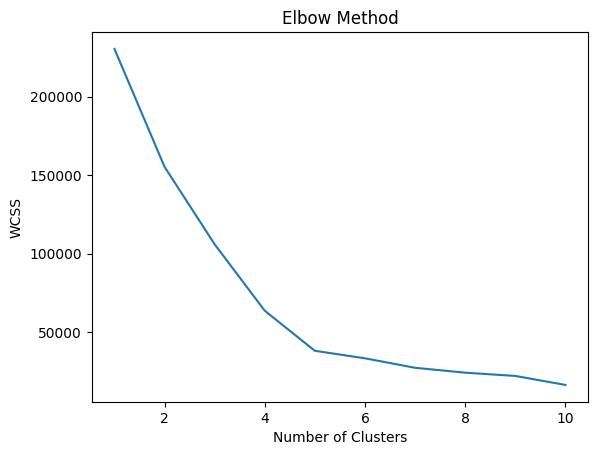

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_train)

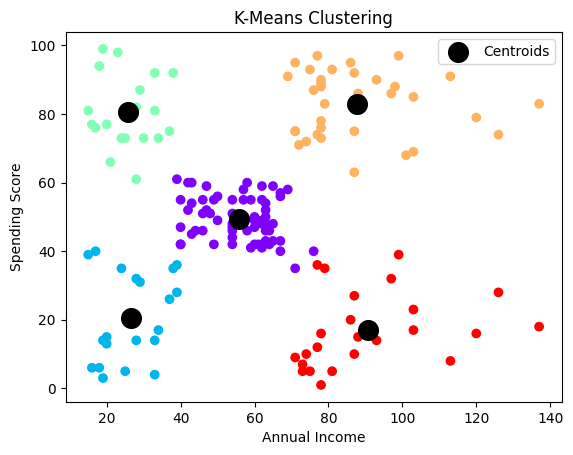

In [ ]:
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_kmeans, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

6. Hierarchical Clustering
   Dendrogram

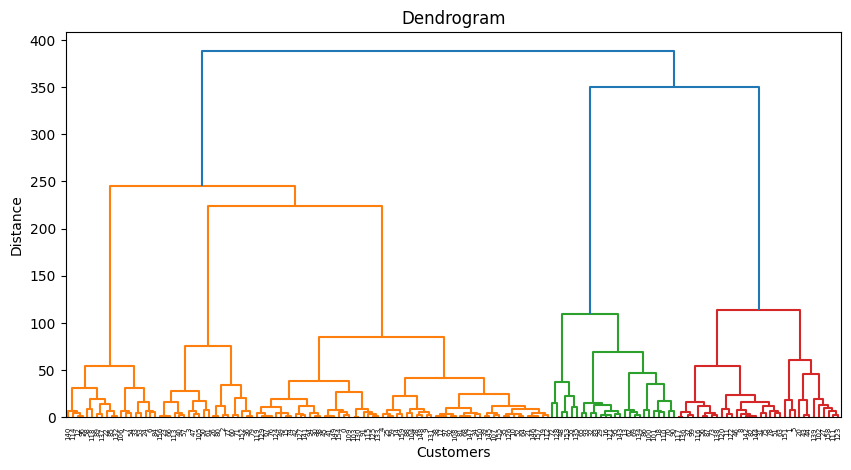

In [ ]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,5))
dendrogram = sch.dendrogram(sch.linkage(X_train, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

Apply Hierarchical Clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X_train)

Visualization

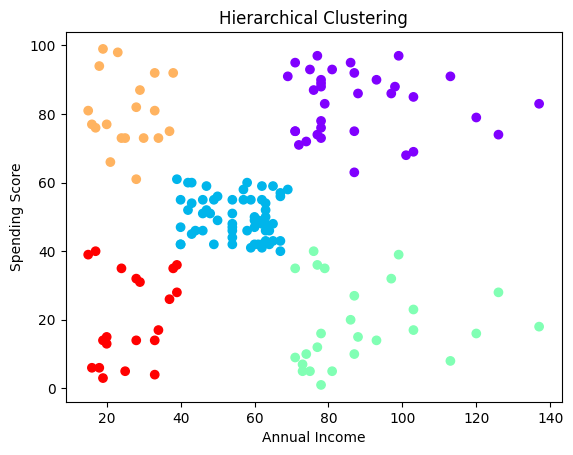

In [ ]:
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_hc, cmap='rainbow')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering")
plt.show()

7. Model Evaluation (Important!)

Since clustering has no labels, we use:
Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(X_train, y_kmeans)
score_hc = silhouette_score(X_train, y_hc)

print("K-Means Silhouette Score:", score_kmeans)
print("Hierarchical Silhouette Score:", score_hc)

K-Means Silhouette Score: 0.5502062330283519
Hierarchical Silhouette Score: 0.5446226502499154
